In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
import torch
torch.cuda.empty_cache()
np.random.seed(2026)
torch.manual_seed(101)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(101)
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import linalg as la
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch


print (torch.__version__, torch.cuda.is_available())
print(torch.version.cuda)
print (torch.cuda.get_device_name())
# device= 'cpu'
device= 'cuda'

2.3.1 True
11.8
NVIDIA GeForce RTX 3070 Ti


In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
def ou_process_1d(theta=1, mu=0, sigma=1, X0=0, n_steps=10000, n_eval=200, h=1e-5):
    """
    Simulates the Ornstein-Uhlenbeck process.
    
    Parameters:
    - theta: rate of mean reversion
    - mu: long-term mean of the process
    - sigma: volatility
    - X0: initial value
    - n_steps: number of steps in each evaluation
    - n_eval: number of evaluations
    - h: Integration step size
    
    Returns:
    - A numpy array containing the simulated values at each evaluation
    """
    X_eval = np.zeros(n_eval)
    X = X0
    
    for i in range(n_eval):
        for _ in range(n_steps):
            dW = np.sqrt(h) * np.random.randn()
            X = X + theta * (mu - X) * h + sigma * dW
        X_eval[i] = X
    
    return X_eval

## Setup the parameters
theta = 1
mu = 0
sigma = 1

In [4]:
# Generate m initial points from the domain space [-2, 2]
m = 10
n_eval = 200
n_steps = 1000
h = 1e-4
lag_time = n_steps * h
print("lag time: ", lag_time)
X0_values = np.linspace(-2, 2, m)

# Initialize the data_matrix
data_matrix = np.zeros((m, n_eval+1, 1))

# Simulate trajectories for each initial point and store them in the data_matrix
for i, X0 in tqdm(enumerate(X0_values), total=m, desc="Simulating trajectories"):
    X_eval = np.concatenate(([X0], ou_process_1d(theta=theta, mu=mu, sigma=sigma, X0=X0, n_steps=n_steps, n_eval=n_eval, h=h)))
    data_matrix[i, :, 0] = X_eval

# Print the shape of data_matrix
print("Shape of data_matrix:", data_matrix.shape)

# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]
data_x_train = X[:int(0.7*len_all)]
data_x_valid = X[int(0.7*len_all)+1:]

data_y_train = Y[:int(0.7*len_all)]
data_y_valid = Y[int(0.7*len_all)+1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print(data_x_train.shape)

lag time:  0.1


Simulating trajectories:   0%|          | 0/10 [00:00<?, ?it/s]

Simulating trajectories:  10%|█         | 1/10 [00:00<00:02,  3.68it/s]

Simulating trajectories:  20%|██        | 2/10 [00:00<00:02,  3.69it/s]

Simulating trajectories:  30%|███       | 3/10 [00:00<00:01,  3.68it/s]

...

Simulating trajectories:  80%|████████  | 8/10 [00:02<00:00,  3.71it/s]

Simulating trajectories:  90%|█████████ | 9/10 [00:02<00:00,  3.72it/s]

Simulating trajectories: 100%|██████████| 10/10 [00:02<00:00,  3.72it/s]

Simulating trajectories: 100%|██████████| 10/10 [00:02<00:00,  3.70it/s]

Shape of data_matrix: (10, 201, 1)
Shape of data_X: (10, 200, 1)
Shape of data_Y: (10, 200, 1)
Shape of X: (2000, 1)
Shape of Y: (2000, 1)
(1400, 1)


In [5]:
from solver_edmd_torch_gpu import KoopmanNNTorch, EDMDSolverTorch
#### EDMD Test ####
checkpoint_file= 'ou1d_v2_oldparams_edmd_ckpt.torch'

basis_function = KoopmanNNTorch(input_size=1, layer_sizes=[20, 20], n_psi_train=18).to(device)

solver = EDMDSolverTorch(
    dic=basis_function,
    target_dim=np.shape(data_x_train)[-1],
    reg=0.1,
    checkpoint_file=checkpoint_file,
    batch_size=32
)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

In [6]:
solver.build_with_edmd(
    data_train=data_train,
    data_valid=data_valid,
    epochs=500,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=0.8
)

Outer Epoch 1/500
Epoch: 1 	Training Loss: 0.007509 val loss: 0.007518
saving, val loss enhanced: 0.007518485770019018 1000000000000000.0
Epoch: 2 	Training Loss: 0.007488 val loss: 0.007498
saving, val loss enhanced: 0.00749811107329269 0.007518485770019018
Epoch: 3 	Training Loss: 0.007468 val loss: 0.007478
saving, val loss enhanced: 0.007478020949370043 0.00749811107329269
Outer Epoch 2/500
Epoch: 1 	Training Loss: 0.007447 val loss: 0.007457
saving, val loss enhanced: 0.007457243745089178 0.007478020949370043


Epoch: 2 	Training Loss: 0.007427 val loss: 0.007437
saving, val loss enhanced: 0.007437174397048297 0.007457243745089178
Epoch: 3 	Training Loss: 0.007406 val loss: 0.007418
saving, val loss enhanced: 0.007417544849110994 0.007437174397048297
Outer Epoch 3/500
Epoch: 1 	Training Loss: 0.007386 val loss: 0.007397
saving, val loss enhanced: 0.007396935181332591 0.007417544849110994
Epoch: 2 	Training Loss: 0.007366 val loss: 0.007377
saving, val loss enhanced: 0.007377363319501012 0.007396935181332591
Epoch: 3 	Training Loss: 0.007347 val loss: 0.007358
saving, val loss enhanced: 0.007358108525589697 0.007377363319501012
Outer Epoch 4/500
Epoch: 1 	Training Loss: 0.007326 val loss: 0.007338
saving, val loss enhanced: 0.007338081004853173 0.007358108525589697


Epoch: 2 	Training Loss: 0.007307 val loss: 0.007319
saving, val loss enhanced: 0.0073188813211387035 0.007338081004853173
Epoch: 3 	Training Loss: 0.007288 val loss: 0.007300
saving, val loss enhanced: 0.007299896050495186 0.0073188813211387035
Outer Epoch 5/500
Epoch: 1 	Training Loss: 0.007268 val loss: 0.007280
saving, val loss enhanced: 0.007280017679014729 0.007299896050495186
Epoch: 2 	Training Loss: 0.007249 val loss: 0.007261
saving, val loss enhanced: 0.007261349301472602 0.007280017679014729
Epoch: 3 	Training Loss: 0.007230 val loss: 0.007243
saving, val loss enhanced: 0.007243101253303755 0.007261349301472602
Outer Epoch 6/500
Epoch: 1 	Training Loss: 0.007211 val loss: 0.007224
saving, val loss enhanced: 0.007223859375808139 0.007243101253303755
Epoch: 2 	Training Loss: 0.007192 val loss: 0.007205
saving, val loss enhanced: 0.007205498879797369 0.007223859375808139


Epoch: 3 	Training Loss: 0.007174 val loss: 0.007188
saving, val loss enhanced: 0.007187589969054779 0.007205498879797369
Outer Epoch 7/500
Epoch: 1 	Training Loss: 0.007155 val loss: 0.007169
saving, val loss enhanced: 0.0071687058829404005 0.007187589969054779
Epoch: 2 	Training Loss: 0.007137 val loss: 0.007151
saving, val loss enhanced: 0.007150615825542126 0.0071687058829404005
Epoch: 3 	Training Loss: 0.007119 val loss: 0.007133
saving, val loss enhanced: 0.00713298797853004 0.007150615825542126
Outer Epoch 8/500
Epoch: 1 	Training Loss: 0.007101 val loss: 0.007115
saving, val loss enhanced: 0.00711464047149875 0.00713298797853004
Epoch: 2 	Training Loss: 0.007083 val loss: 0.007097
saving, val loss enhanced: 0.007096930433227415 0.00711464047149875
Epoch: 3 	Training Loss: 0.007065 val loss: 0.007079
saving, val loss enhanced: 0.007079402502003829 0.007096930433227415
Outer Epoch 9/500


Epoch: 1 	Training Loss: 0.007047 val loss: 0.007061
saving, val loss enhanced: 0.007061270021936375 0.007079402502003829
Epoch: 2 	Training Loss: 0.007029 val loss: 0.007044
saving, val loss enhanced: 0.007044127557183486 0.007061270021936375
Epoch: 3 	Training Loss: 0.007013 val loss: 0.007027
saving, val loss enhanced: 0.007027245279330323 0.007044127557183486
Outer Epoch 10/500
Epoch: 1 	Training Loss: 0.006995 val loss: 0.007010
saving, val loss enhanced: 0.007009607557684828 0.007027245279330323
Epoch: 2 	Training Loss: 0.006977 val loss: 0.006993
saving, val loss enhanced: 0.006992952418880508 0.007009607557684828


...

Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535795828776431 0.004535815849503992
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535769170284835 0.004535795828776431
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535733757361779 0.004535769170284835
Outer Epoch 493/500
Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004536
Outer Epoch 494/500


Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004536
Outer Epoch 495/500
Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535695147847884 0.004535733757361779
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535680338184644 0.004535695147847884
Outer Epoch 496/500


Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535652155915814 0.004535680338184644
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.00453564336226564 0.004535652155915814
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.0045356218235260955 0.00453564336226564
Outer Epoch 497/500
Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535603968255857 0.0045356218235260955
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004536
Outer Epoch 498/500


Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.00453559974764021 0.004535603968255857
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535565718770916 0.00453559974764021
Outer Epoch 499/500
Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.004535539107126727 0.004535565718770916
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
saving, val loss enhanced: 0.0045355052613152555 0.004535539107126727
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004535
saving, val loss enhanced: 0.0045354820940182354 0.0045355052613152555
Outer Epoch 500/500


Epoch: 1 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 2 	Training Loss: 0.004512 val loss: 0.004536
Epoch: 3 	Training Loss: 0.004512 val loss: 0.004535


In [7]:
# Results from solver_edmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    'K': Koopman_matrix_K
    }

[-4.0000e-04 -1.0077e+00 -3.6111e+00 -7.3825e+00]


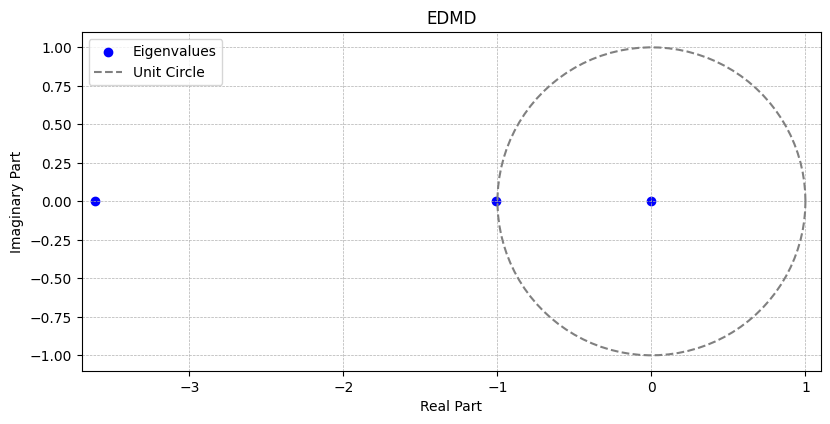

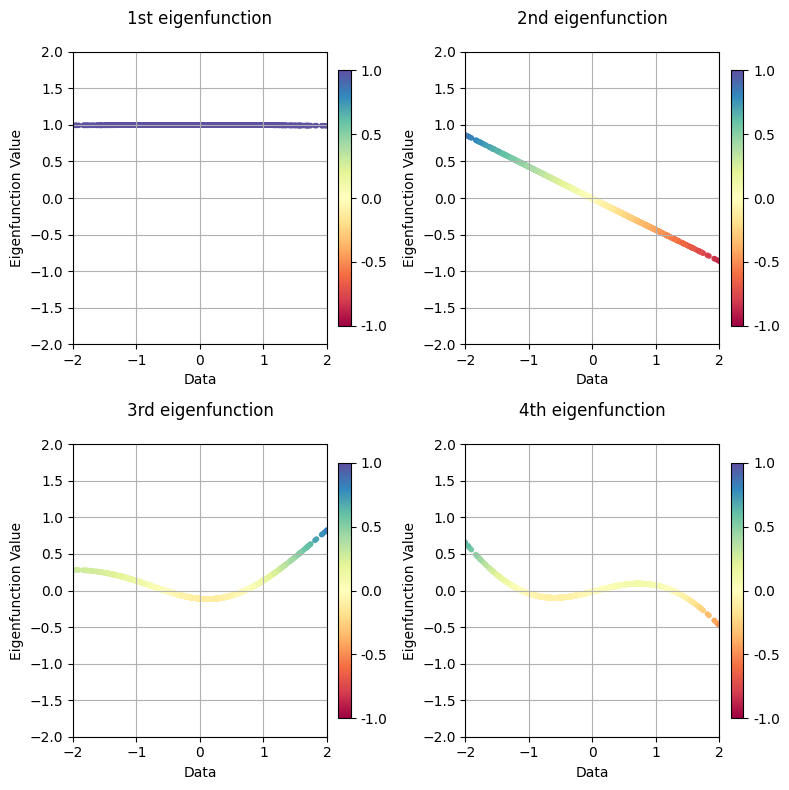

In [8]:
# Take ln values of the eigenvalues and divide by 0.1
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues = (evalues[:4]-1) / lag_time
ln_evalues_display = np.real_if_close(ln_evalues, tol=1000).real

print(np.round(ln_evalues_display, 4))

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_display
imag_parts = np.zeros_like(real_parts)

# Create the plot
plt.figure(figsize=(9.6, 4.4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('EDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.xlim(-3.7, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('SDMD', fontsize=20)
plt.tight_layout()
plt.show()

In [9]:
from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch
#### SDMD Test ####
checkpoint_file= 'ou1d_v2_oldparams_sdmd_ckpt.torch'

np.random.seed(101)
torch.manual_seed(101)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(101)

basis_function = KoopmanNNTorch(input_size=1, layer_sizes=[20, 20], n_psi_train=18).to(device)

solver = KoopmanSolverTorch(dic=basis_function, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                       reg=0.1,  checkpoint_file= checkpoint_file, fnn_checkpoint_file= 'ou1d_v2_oldparams_sdmd_fnn_ckpt.torch', a_b_file= 'ou1d_v2_oldparams_sdmd_a_b.jbl',
                generator_batch_size= 4, fnn_batch_size= 32, delta_t= lag_time)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

In [10]:
solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=500,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8
    )

Epoch: 1 	Training Loss: 0.387317 	Validation Loss: 0.306337
Saving model, validation loss improved: 0.306337 < 10000.000000
Epoch: 2 	Training Loss: 0.216019 	Validation Loss: 0.186408
Saving model, validation loss improved: 0.186408 < 0.306337
Epoch: 3 	Training Loss: 0.135811 	Validation Loss: 0.134031
Saving model, validation loss improved: 0.134031 < 0.186408


Epoch: 4 	Training Loss: 0.106652 	Validation Loss: 0.121440
Saving model, validation loss improved: 0.121440 < 0.134031
Epoch: 5 	Training Loss: 0.099701 	Validation Loss: 0.118502
Saving model, validation loss improved: 0.118502 < 0.121440
Epoch: 6 	Training Loss: 0.098230 	Validation Loss: 0.117238
Saving model, validation loss improved: 0.117238 < 0.118502


Epoch: 7 	Training Loss: 0.097305 	Validation Loss: 0.116613
Saving model, validation loss improved: 0.116613 < 0.117238
Epoch: 8 	Training Loss: 0.096040 	Validation Loss: 0.115565
Saving model, validation loss improved: 0.115565 < 0.116613
Epoch: 9 	Training Loss: 0.094637 	Validation Loss: 0.114858
Saving model, validation loss improved: 0.114858 < 0.115565


Epoch: 10 	Training Loss: 0.094479 	Validation Loss: 0.114239
Saving model, validation loss improved: 0.114239 < 0.114858
Epoch: 11 	Training Loss: 0.093282 	Validation Loss: 0.113605
Saving model, validation loss improved: 0.113605 < 0.114239
Epoch: 12 	Training Loss: 0.092680 	Validation Loss: 0.113096
Saving model, validation loss improved: 0.113096 < 0.113605


Epoch: 13 	Training Loss: 0.092305 	Validation Loss: 0.112660
Saving model, validation loss improved: 0.112660 < 0.113096
Epoch: 14 	Training Loss: 0.092052 	Validation Loss: 0.112141
Saving model, validation loss improved: 0.112141 < 0.112660
Epoch: 15 	Training Loss: 0.091078 	Validation Loss: 0.111847
Saving model, validation loss improved: 0.111847 < 0.112141


...

Processing batches:   0%|          | 0/22 [00:00<?, ?batch/s]

Processing batches:  73%|███████▎  | 16/22 [00:00<00:00, 150.44batch/s]

Processing batches: 100%|██████████| 22/22 [00:00<00:00, 147.42batch/s]

Epoch: 1 	Training Loss: 0.004540 val loss: 0.004548


Epoch: 2 	Training Loss: 0.004540 val loss: 0.004548
EarlyStopping counter: 1 out of 7
Epoch 500 time: 0.22 seconds


In [11]:
# Results from solver_sdmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    'K': Koopman_matrix_K
    }

[-0.     -1.0063 -2.0215 -3.0227]


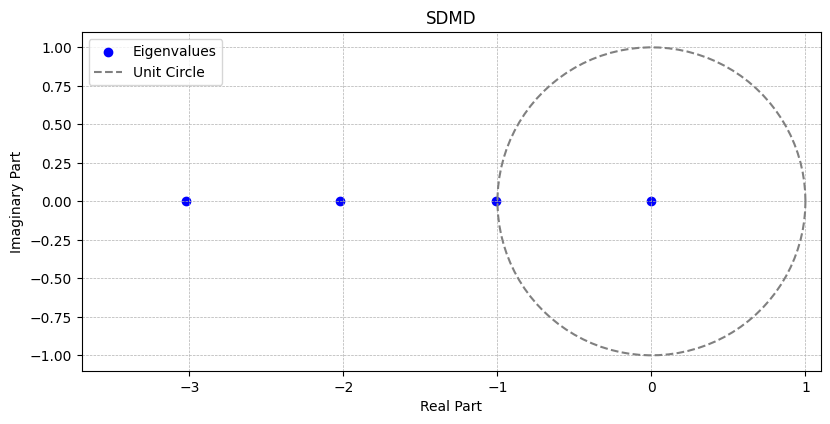

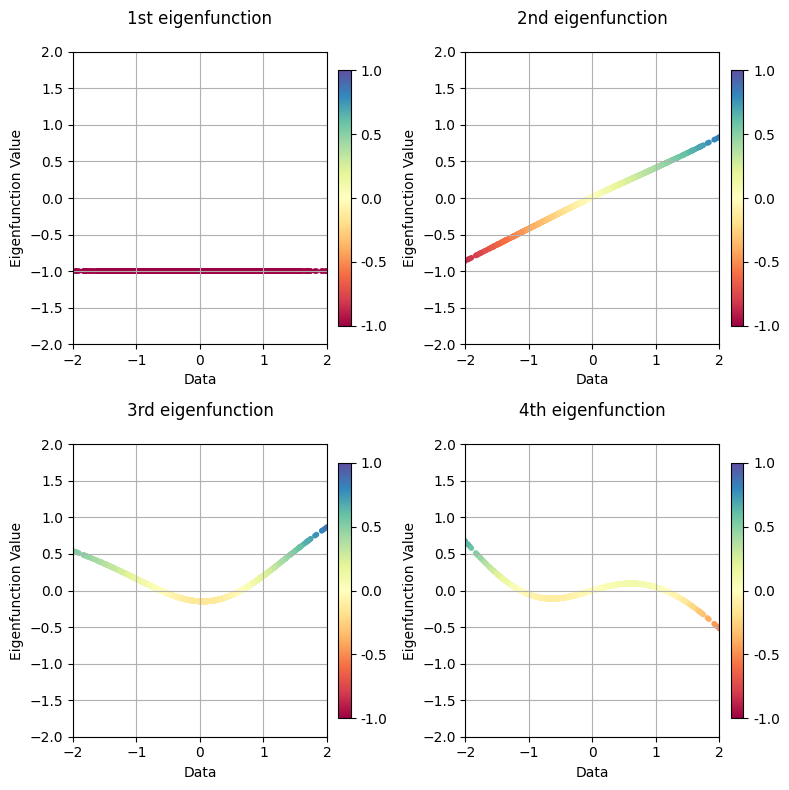

In [12]:
# Take ln values of the eigenvalues and divide by 0.1
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues = (evalues[:4]-1) / lag_time
ln_evalues_display = np.real_if_close(ln_evalues, tol=1000).real

print(np.round(ln_evalues_display, 4))

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_display
imag_parts = np.zeros_like(real_parts)

# Create the plot
plt.figure(figsize=(9.6, 4.4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('SDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.xlim(-3.7, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('SDMD', fontsize=20)
plt.tight_layout()
plt.show()

In [13]:
from solver_gedmd_torch_gpu import KoopmanNNTorch as KoopmanNNTorch_g
from solver_gedmd_torch_gpu import  KoopmanSolverTorch as KoopmanSolverTorch_g
#### gEDMD Test ####
checkpoint_file_g= 'ou1d_v2_oldparams_gedmd_ckpt.torch'
basis_function_g = KoopmanNNTorch_g(input_size=1, layer_sizes=[20, 20], n_psi_train=18).to(device)

solver_g = KoopmanSolverTorch_g(dic=basis_function_g, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                       reg=0.1,  checkpoint_file= checkpoint_file_g, fnn_checkpoint_file= 'ou1d_v2_oldparams_sdmd_fnn_ckpt.torch',  a_b_file= 'ou1d_v2_oldparams_sdmd_a_b.jbl',
                generator_batch_size= 4, fnn_batch_size= 32)

In [14]:
solver_g.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=500,
    batch_size=32,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8,
    )

Epoch: 1 	Training Loss: 0.309176 	Validation Loss: 0.224110
Saving model, validation loss improved: 0.224110 < 10000.000000
Epoch: 2 	Training Loss: 0.175486 	Validation Loss: 0.138279
Saving model, validation loss improved: 0.138279 < 0.224110
Epoch: 3 	Training Loss: 0.116718 	Validation Loss: 0.110300
Saving model, validation loss improved: 0.110300 < 0.138279


Epoch: 4 	Training Loss: 0.101609 	Validation Loss: 0.104586
Saving model, validation loss improved: 0.104586 < 0.110300
Epoch: 5 	Training Loss: 0.099372 	Validation Loss: 0.103964
Saving model, validation loss improved: 0.103964 < 0.104586
Epoch: 6 	Training Loss: 0.098943 	Validation Loss: 0.103418
Saving model, validation loss improved: 0.103418 < 0.103964


Epoch: 7 	Training Loss: 0.098112 	Validation Loss: 0.103177
Saving model, validation loss improved: 0.103177 < 0.103418
Epoch: 8 	Training Loss: 0.098113 	Validation Loss: 0.102742
Saving model, validation loss improved: 0.102742 < 0.103177
Epoch: 9 	Training Loss: 0.097428 	Validation Loss: 0.102205
Saving model, validation loss improved: 0.102205 < 0.102742


Epoch: 10 	Training Loss: 0.096780 	Validation Loss: 0.101881
Saving model, validation loss improved: 0.101881 < 0.102205
Epoch: 11 	Training Loss: 0.095916 	Validation Loss: 0.100828
Saving model, validation loss improved: 0.100828 < 0.101881
Epoch: 12 	Training Loss: 0.096193 	Validation Loss: 0.100855


Epoch: 13 	Training Loss: 0.096053 	Validation Loss: 0.099750
Saving model, validation loss improved: 0.099750 < 0.100828
Epoch: 14 	Training Loss: 0.095009 	Validation Loss: 0.099171
Saving model, validation loss improved: 0.099171 < 0.099750
Epoch: 15 	Training Loss: 0.095102 	Validation Loss: 0.098564
Saving model, validation loss improved: 0.098564 < 0.099171


...

Processing batches:   0%|          | 0/22 [00:00<?, ?batch/s]

Processing batches:  77%|███████▋  | 17/22 [00:00<00:00, 165.99batch/s]

Processing batches: 100%|██████████| 22/22 [00:00<00:00, 166.37batch/s]

EarlyStopping counter: 7 out of 7
Early stopping triggered


([0.0014626114052768485,
  0.001463264065451539,
  0.0014639174921271213,
  0.0014645716869465608,
  0.0014652266514030006,
  0.001465882386836158,
  0.0014665388944291005,
  0.001467196175205505],
 0.0014626114052768485)

In [15]:
solver_g.eig_decomp()  # Do spectral decomposition to generate eigenvalues and eigenvectors

evalues = solver_g.eigenvalues.T
efuns = solver_g.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Psi_X = solver_g.get_Psi_X()
Psi_Y = solver_g.get_Psi_Y()
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict
}

[ 0.     -3.5053 -2.0971 -1.0358]


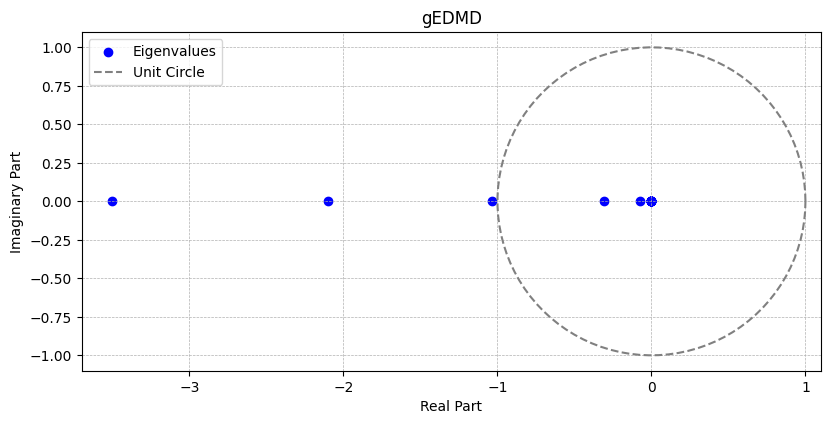

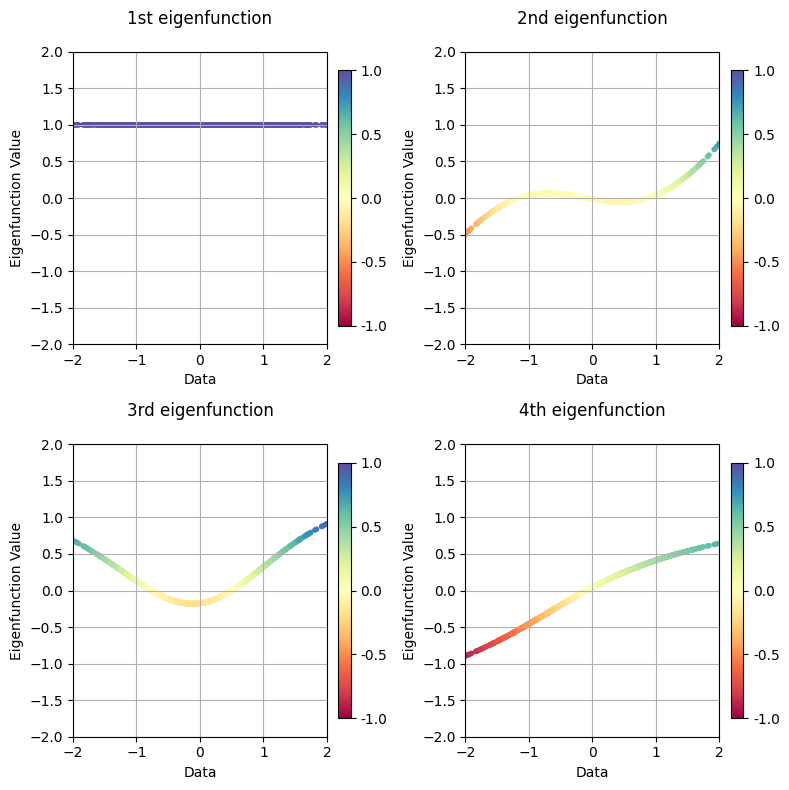

In [16]:
evalues_display = np.real_if_close(evalues, tol=1000).real
print(np.round(evalues_display[:4], 4))

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = evalues_display
imag_parts = np.zeros_like(real_parts)

# Create the plot
plt.figure(figsize=(9.6, 4.4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('gEDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.xlim(-3.7, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('gEDMD', fontsize=20)
plt.tight_layout()
plt.show()